In [3]:
import math 
import numpy as np 
import matplotlib.pyplot as plt 

In [39]:
# The Value class 
class Value: 
    def __init__(self, data, _children=(), _op='', label=""):
        self.data = data 
        self._backward = lambda: None # This will store the function that does that chain rule at every node 
        self.grad = 0.0 
        self._prev = set(_children)
        self._op = _op 
        self.label = label 
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            # implementing the chain rule for gradient calculation over addition 
            # The local derivative for addition is always 1 
            # The upstream derivative in our logic is out.grad 
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad 

        out._backward = _backward 
        return out 

    def __mul__(self, other): 
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            # for a gradient calculation over multiplication, we swap the inputs data and multiply by the upstream gradient 
            self.grad += other.data * out.grad 
            other.grad += self.data * out.grad 

        out._backward = _backward 
        return out  
    
    def tanh(self):
        x = self.data 
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), "tanh")

        def _backward(): 
            self.grad += (1 - t**2) * out.grad # The local gradient 1 - t**2 has to be multiplied by the upstream gradient out.grad because of the chain rule 

        out._backward = _backward 
        return out 
    
    def backward(self):
        # Topological sort 
        topo = [] 
        visited = set() 
        def build_topo(v):
            if v not in visited: 
                visited.add(v)
                for child in v._prev: 
                    build_topo(child)
                topo.append(v) 
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [5]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [31]:
# A simple 2-dimensional neuron 

# inputs 
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights 
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron 
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2w2 + b 
x1w1 = x1 * w1; x1w1.label = "x1w1"
x2w2 = x2 * w2; x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

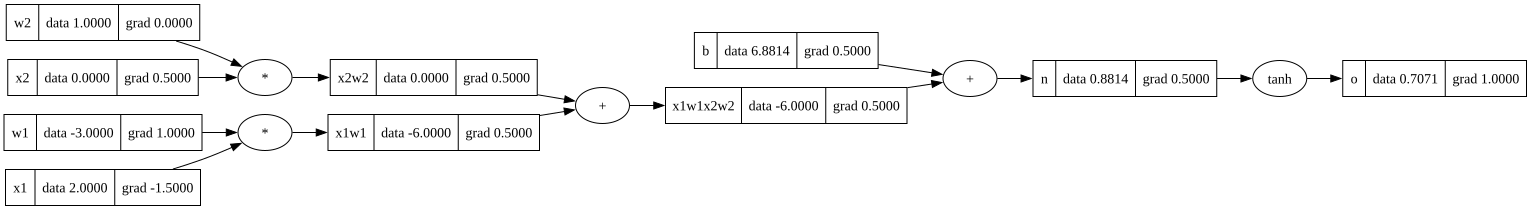

In [36]:
draw_dot(o)

In [35]:
o.backward()

In [12]:
# We have to explicitly set o.grad to 1.0 as a base case 
o.grad = 1.0 

In [33]:
o._backward()

In [15]:
n._backward()

In [17]:
x1w1x2w2._backward()
b._backward()

In [19]:
x1w1._backward()
x2w2._backward()

In [24]:
# Topological sort 
o.grad = 1.0 

topo = [] 
visited = set() 
def build_topo(v):
    if v not in visited: 
        visited.add(v)
        for child in v._prev: 
            build_topo(child)
        topo.append(v)

build_topo(o)

for node in reversed(topo):
    node._backward()

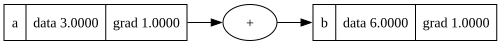

In [ ]:
# There is a bug in the Logic implementation 
# Each time a variable in the expression is used more than once as shown below, the gradients get overridden which results in the wrong output 

# See this example below 

a = Value(3.0, label='a')
b = a + a; b.label = 'b'  
b.backward()
draw_dot(b)

# b = a + a; just from this expression, we see that the derivative of b with repect to a is 1 + 1 = 2 
# or you can say b = a + a which is also b = 2a whose derivative is 2 
# but the backward gradient shows 1.0 which is wrong 
# Another way to look at it is that we know that the chain rule says local gradient * upstream gradient 
# upstream gradient = 1.0 
# We have learned that the local gradient over addition is simply 1
# but the expression is b = a + a, so we have to add 1 + 1 which is 2 based on the multivariate chain rule 
# The multivariable chain rule states that if single variable branches out and influences the final output through multiple paths,
# its total derivative is the sum of the derivatives along all paths 

# So during our logic in the Value class, we use += which accumulate the gradients. 
# This ensures that each time a node is visited multiple times, it gracefully adds the gradients instead of overididing it 

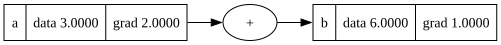

In [40]:
# So when we re-run this expression, we get the correct gradients as shown below 

a = Value(3.0, label='a')
b = a + a; b.label = 'b'  
b.backward()
draw_dot(b)